In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB
None


Сгруппируйте данные по дате, посчитайте количество продаж

In [7]:
grouped_df = df.groupby('Дата')['Количество'].sum()

In [8]:
grouped_df

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64

Вывести несколько первых строк сгруппированных данных

In [9]:
print(grouped_df.head())

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64


Нарисуйте график продаж у `grouped_df`

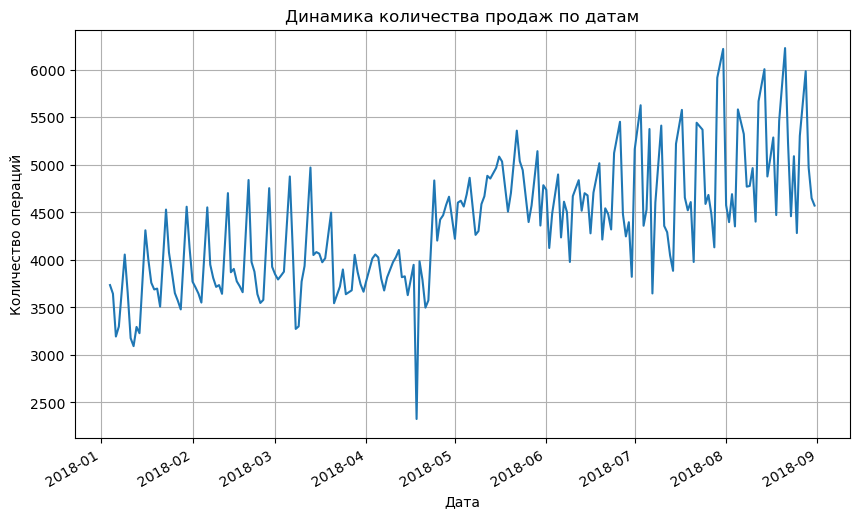

In [10]:
grouped_df.plot(x='Дата', y='Количество_продаж', figsize=(10, 6), grid=True)

plt.title('Динамика количества продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество операций')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [11]:
# Дела идут в гору: С января по сентябрь продажи заметно выросли. Если в начале года за день их было около 3500, то к концу лета стало доходить до 6000.
# Постоянные «скачки»: График похож на забор или пилу. Это значит, что продажи идут неровно: скорее всего, в будни работы много, а на выходных всё затихает. И так каждую неделю.
# Странный провал в апреле: В середине апреля продажи почему-то резко рухнули. Возможно, был какой-то сбой в системе или просто длинные праздники.
# Осенью «штормит» сильнее: Если весной разница между удачным и тихим днем была небольшой, то к августу эти «качели» стали намного сильнее.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [14]:
max_row_index = df['Количество'].idxmax()

In [15]:
outlier_row = df.loc[max_row_index]
print(outlier_row)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [18]:
weather_df = pd.read_excel('weather.xlsx')

In [19]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1918 entries, 0 to 1917
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Дата    1918 non-null   datetime64[ns]
 1   T       1918 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 30.1 KB


In [28]:
daily_temp = weather_df.groupby(weather_df['Дата'].dt.date)['T'].mean().reset_index()

In [30]:
sales_df = grouped_df.reset_index()
sales_df['Дата'] = pd.to_datetime(sales_df['Дата']).dt.date

In [33]:
merged_df = pd.merge(sales_df, daily_temp, on='Дата')

In [36]:
merged_df = merged_df.rename(columns={'Количество': 'Количество продаж'})

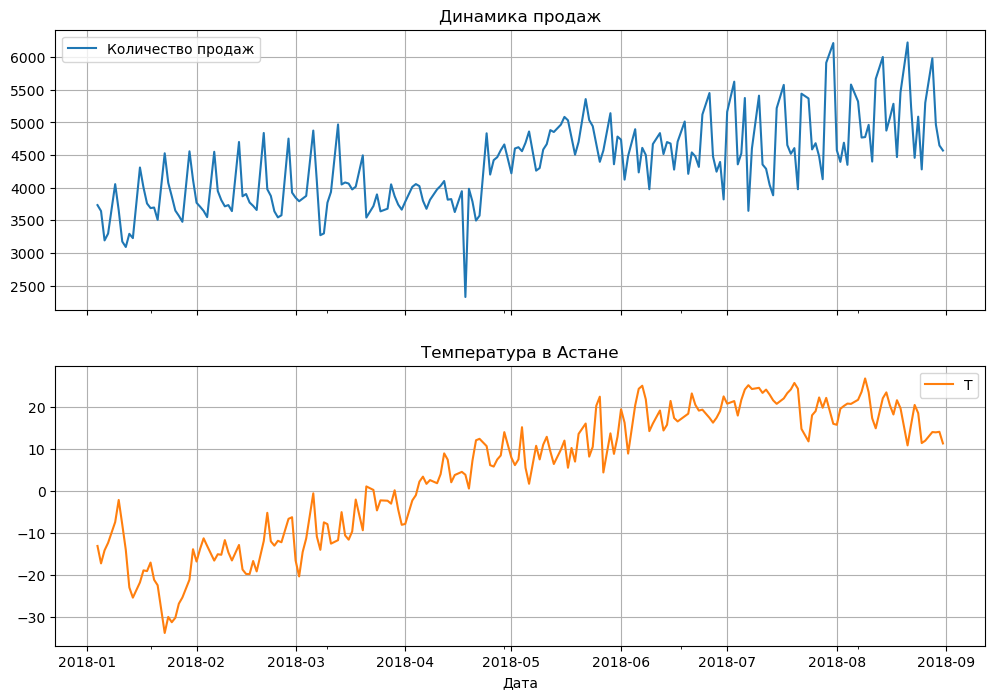

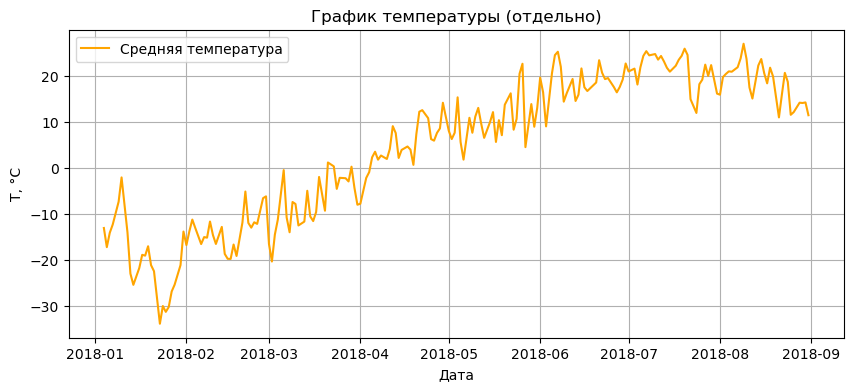

In [49]:
merged_df.plot(x='Дата', y=['Количество продаж', 'T'], subplots=True, 
               figsize=(12, 8), title=['Динамика продаж', 'Температура в Астане'], grid=True)
plt.show()
plt.figure(figsize=(10, 4))
plt.plot(merged_df['Дата'], merged_df['T'], color='orange', label='Средняя температура')
plt.title('График температуры (отдельно)')
plt.xlabel('Дата')
plt.ylabel('T, °C')
plt.legend()
plt.grid(True)
plt.show()